In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ตั้งค่าให้กราฟแสดงเต็ม
%matplotlib inline
sns.set(style="whitegrid")

# อ่านไฟล์ csv
df = pd.read_csv("cleandaily-all-years.csv")

# แปลงคอลัมน์ datetime เป็นชนิดวันที่ และตั้งเป็น index
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# ตรวจสอบข้อมูลเบื้องต้น
print(df.info())
df.dtypes
df.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2020-01-01 to 2024-12-31
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   เกิดเหตุ              1827 non-null   int64  
 1   temperature_F         1827 non-null   float64
 2   humidity_%            1827 non-null   float64
 3   wind_speed_kmh        1827 non-null   float64
 4   pressure_in           1827 non-null   float64
 5   vehicles_lt_4_wheels  1827 non-null   float64
 6   vehicles_4_wheels     1827 non-null   float64
 7   vehicles_gt_4_wheels  1827 non-null   float64
 8   day_of_week           1827 non-null   int64  
 9   is_weekend            1827 non-null   int64  
 10  is_holiday            1827 non-null   int64  
 11  year                  1827 non-null   int64  
dtypes: float64(7), int64(5)
memory usage: 185.6 KB
None


,เกิดเหตุ,temperature_F,humidity_%,wind_speed_kmh,pressure_in,vehicles_lt_4_wheels,vehicles_4_wheels,vehicles_gt_4_wheels,day_of_week,is_weekend,is_holiday,year
datetime,,,,,,,,,,,,
2020-01-01,0,80.920417,74.973750,10.312292,29.818750,108.0,540.0,84.0,2,0,1,2020
2020-01-02,0,81.845000,78.113542,8.920417,29.743750,104.0,448.0,96.0,3,0,0,2020
2020-01-03,0,81.638750,75.494583,7.069375,29.708750,95.0,383.0,107.0,4,0,0,2020
2020-01-04,0,85.617708,75.924583,5.467500,29.666042,84.0,345.0,103.0,5,1,0,2020
2020-01-05,0,83.282083,78.663958,4.600208,29.666667,80.0,375.0,97.0,6,1,0,2020


In [2]:
# ดูสถิติพื้นฐาน
df.describe().T


,count,mean,std,min,25%,50%,75%,max
เกิดเหตุ,1827.0,0.163656,0.414725,0.000000,0.000000,0.000000,0.000000,4.000000
temperature_F,1827.0,81.382913,2.222614,73.003333,79.909063,81.443125,82.856250,87.575833
humidity_%,1827.0,83.393200,6.392844,64.090833,78.594479,83.070000,87.963542,100.000000
wind_speed_kmh,1827.0,4.502930,1.941332,0.581250,3.097188,4.181458,5.656354,12.420417
pressure_in,1827.0,29.702890,0.049999,29.576875,29.668542,29.700625,29.734063,29.876667
vehicles_lt_4_wheels,1827.0,88.585112,7.730946,68.000000,83.000000,88.000000,93.000000,122.000000
vehicles_4_wheels,1827.0,424.025725,65.950850,277.000000,377.000000,414.000000,464.000000,754.000000
vehicles_gt_4_wheels,1827.0,99.926108,6.242412,78.000000,96.000000,100.000000,104.000000,121.000000
day_of_week,1827.0,3.000000,2.000548,0.000000,1.000000,3.000000,5.000000,6.000000
is_weekend,1827.0,0.285714,0.451878,0.000000,0.000000,0.000000,1.000000,1.000000


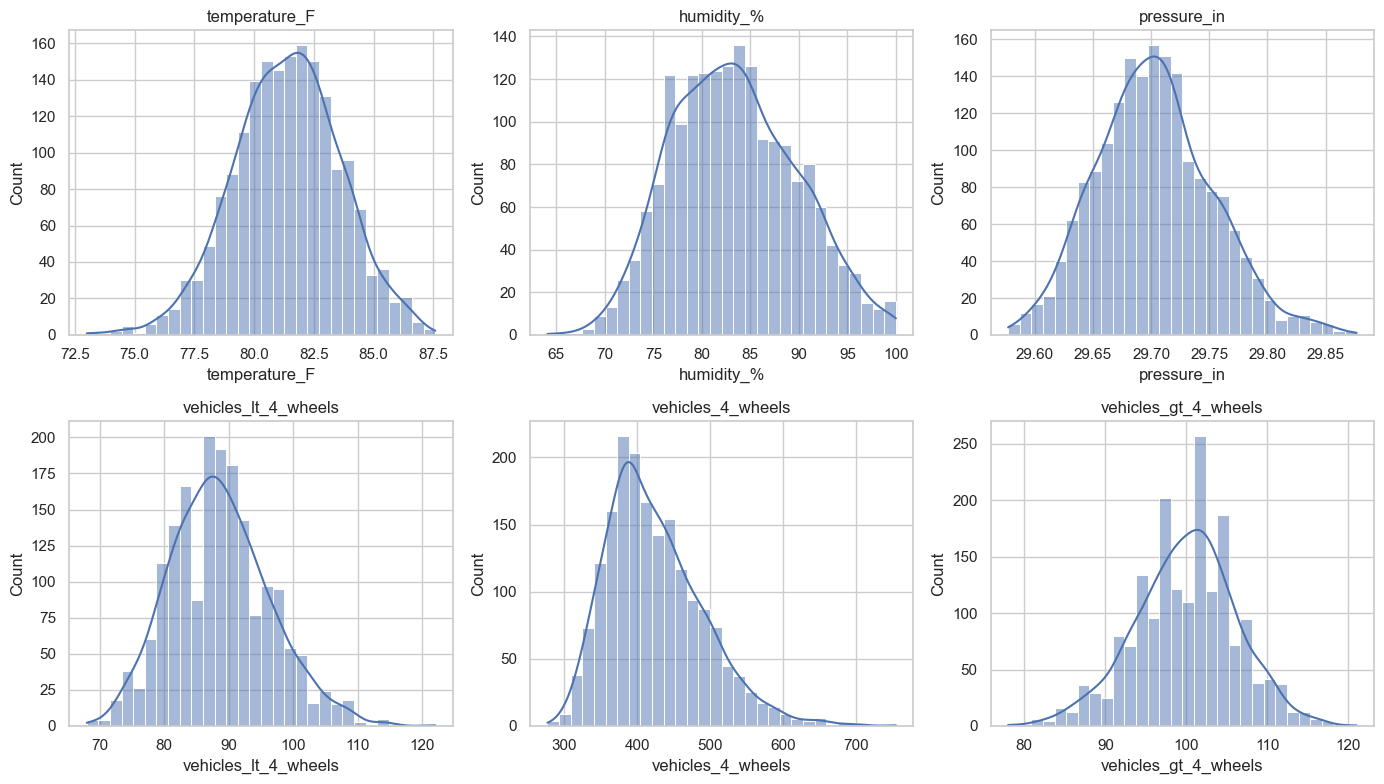

In [3]:
num_cols = ['temperature_F','humidity_%','pressure_in',
            'vehicles_lt_4_wheels','vehicles_4_wheels','vehicles_gt_4_wheels']

plt.figure(figsize=(14,8))
for i, col in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


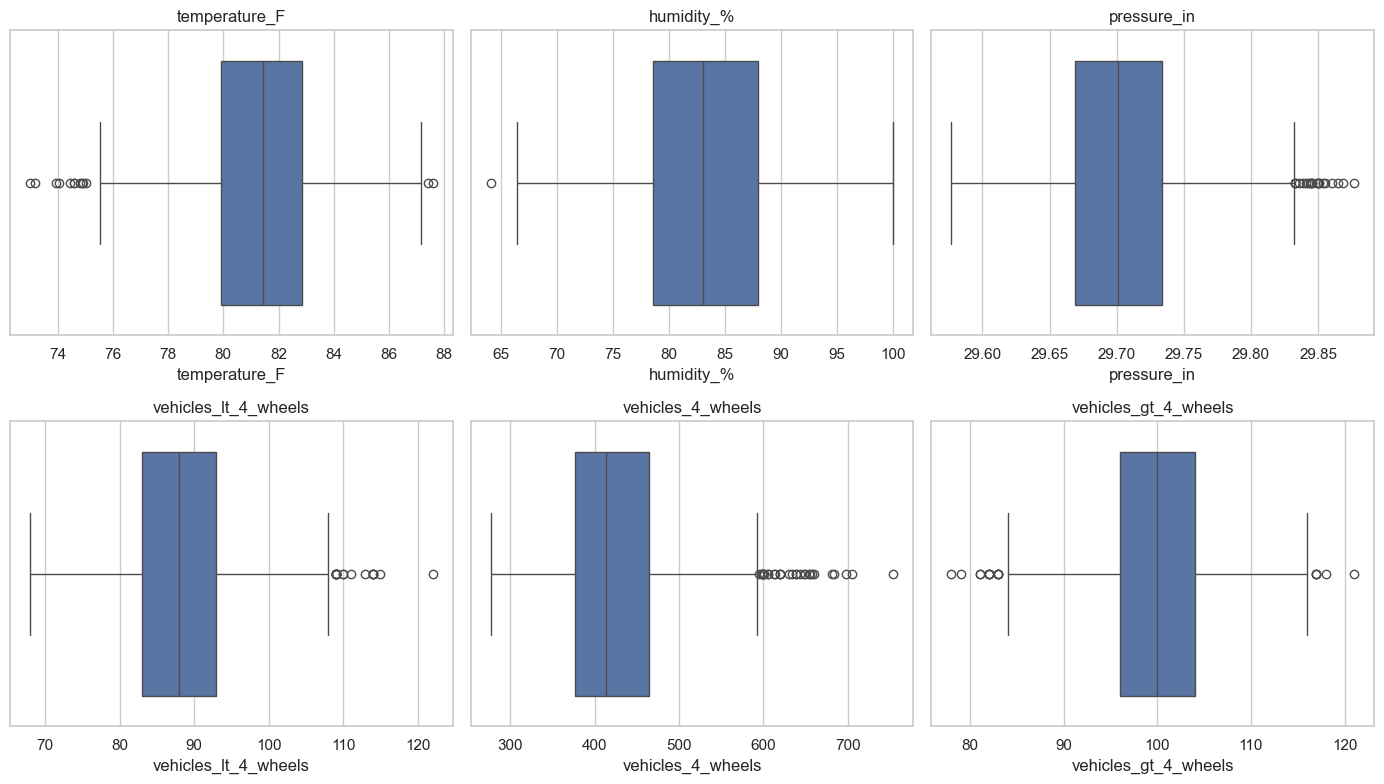

In [4]:
plt.figure(figsize=(14,8))
for i, col in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from c

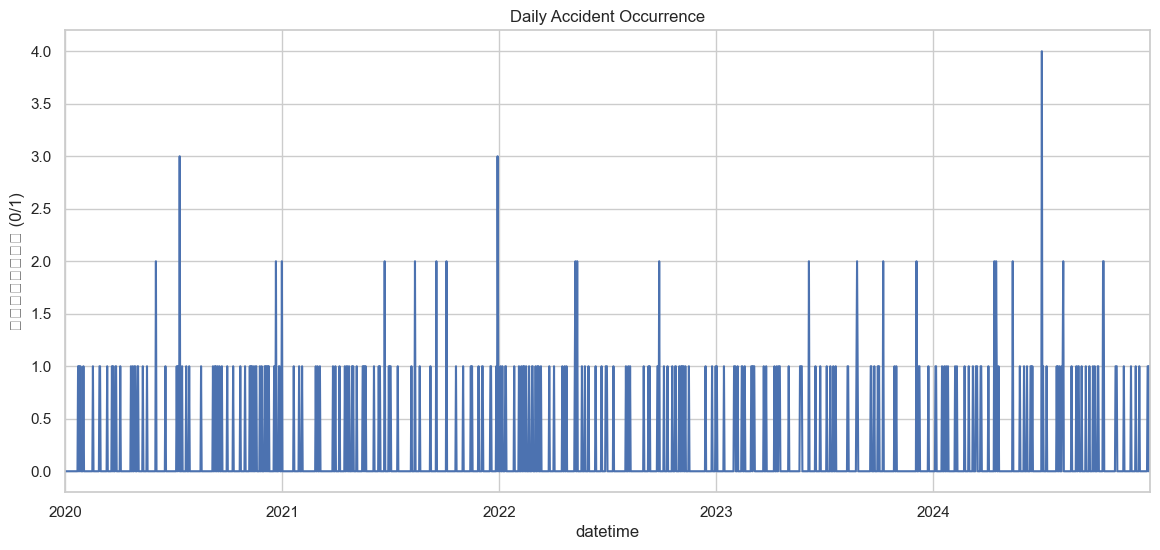

<Figure size 1400x600 with 0 Axes>

c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing fro

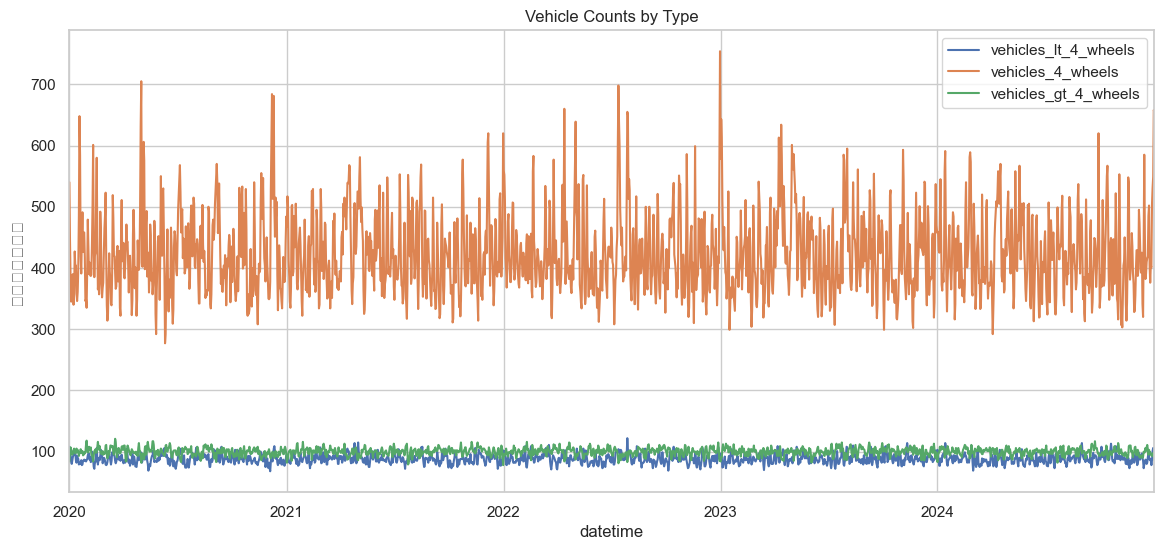

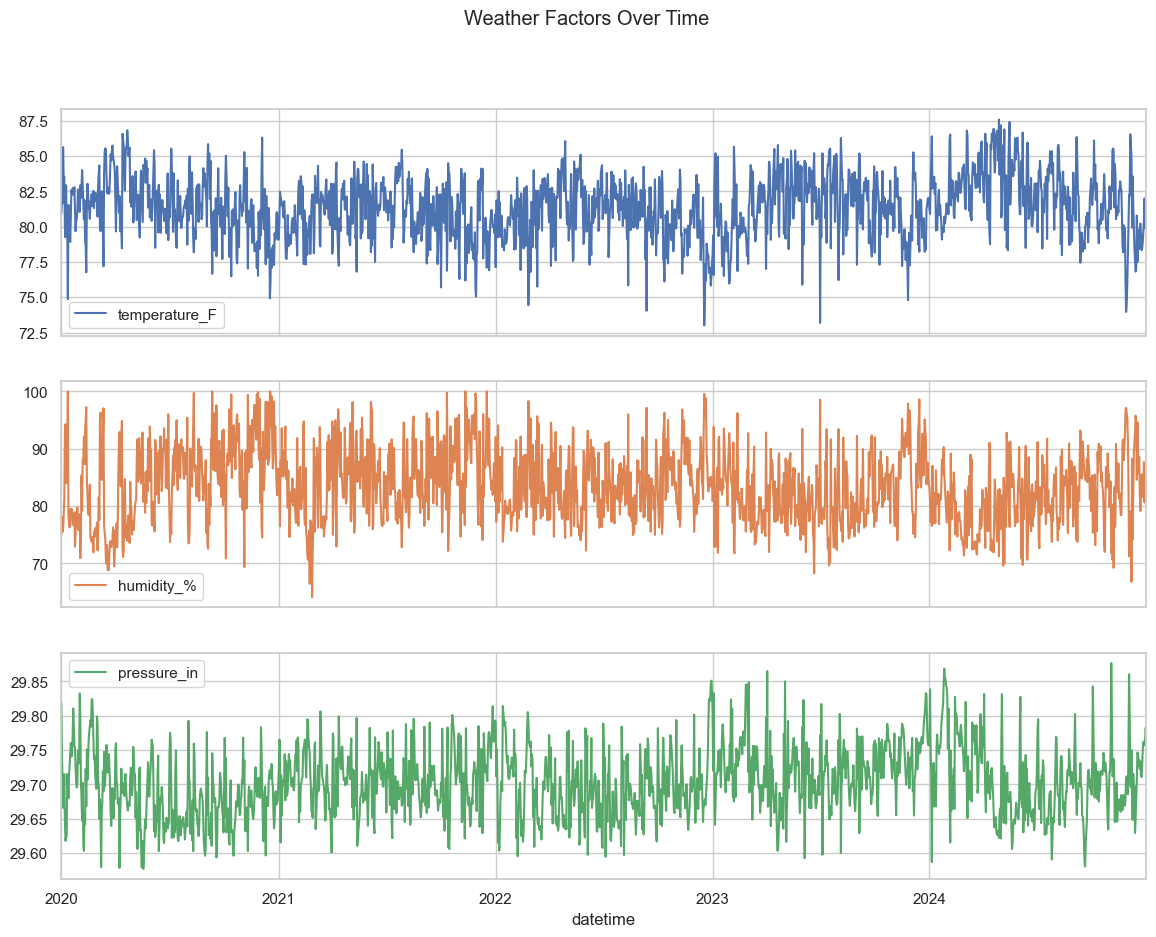

In [5]:
plt.figure(figsize=(14,6))
df['เกิดเหตุ'].plot()
plt.title('Daily Accident Occurrence')
plt.ylabel('เกิดเหตุ (0/1)')
plt.show()

# ปริมาณรถแยกกลุ่ม
plt.figure(figsize=(14,6))
df[['vehicles_lt_4_wheels','vehicles_4_wheels','vehicles_gt_4_wheels']].plot(figsize=(14,6))
plt.title('Vehicle Counts by Type')
plt.ylabel('จำนวนรถ')
plt.show()

# ปัจจัยอากาศ
df[['temperature_F','humidity_%','pressure_in']].plot(subplots=True, figsize=(14,10))
plt.suptitle('Weather Factors Over Time')
plt.show()


c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing fro

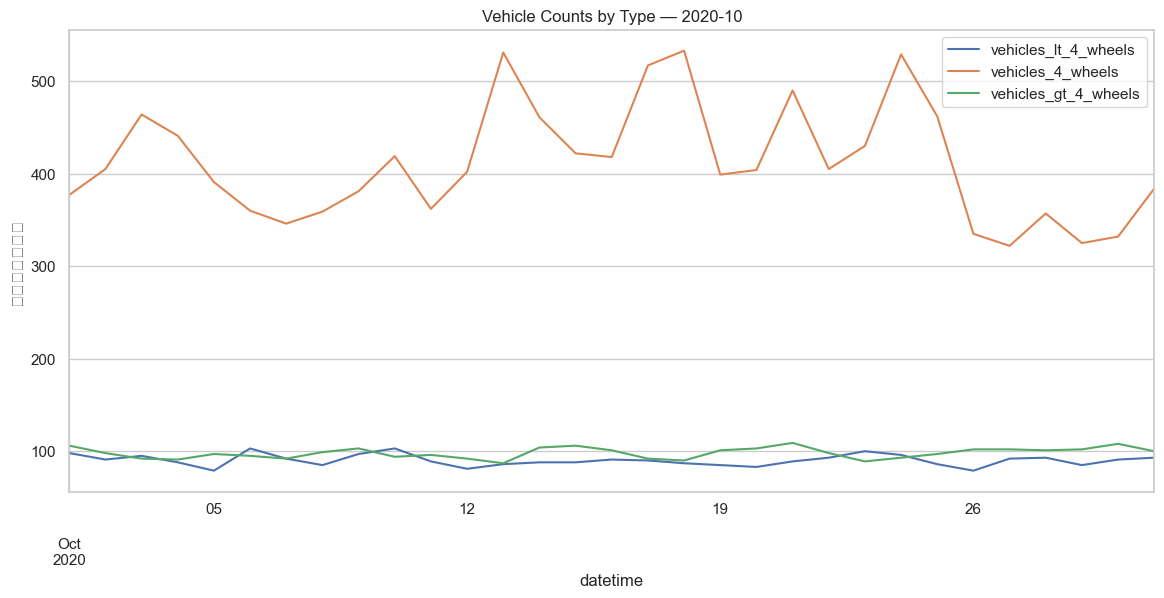

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) ทำชื่อคอลัมน์ให้สะอาดก่อน (กันกรณีมีช่องว่าง)
df = df.copy()
df.columns = df.columns.map(lambda x: str(x).strip())

# 1) สร้าง/กู้คืนคอลัมน์ datetime ให้ได้ชัวร์
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

elif (df.index.name and str(df.index.name).strip().lower() == "datetime") \
     or np.issubdtype(df.index.dtype, np.datetime64):
    # อยู่เป็น index อยู่แล้ว → ย้ายมาเป็นคอลัมน์ชื่อ 'datetime'
    df = df.reset_index().rename(columns={"index":"datetime"})
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

elif {"date","time"}.issubset(df.columns):
    # มี date+time แยกกัน → รวม
    dt_str = df["date"].astype(str).str.strip() + " " + df["time"].astype(str).str.strip()
    # ปรับ dayfirst=True/False ตามรูปแบบไฟล์ของคุณ
    df["datetime"] = pd.to_datetime(dt_str, errors="coerce")  # หรือ format="%Y-%m-%d %H:%M:%S"

else:
    # fallback: ลองใช้คอลัมน์แรกเป็น datetime
    first = df.columns[0]
    df["datetime"] = pd.to_datetime(df[first], errors="coerce")

# 2) เคลียร์ NaT แล้วตั้งเป็น index
df = df.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")

# 3) เลือกเดือนที่อยากดู แล้วพล็อต
year, month = 2020, 10
df_month = df.loc[f"{year}-{month:02d}"]

ax = df_month[["vehicles_lt_4_wheels","vehicles_4_wheels","vehicles_gt_4_wheels"]]\
         .plot(figsize=(14,6))
ax.set_title(f"Vehicle Counts by Type — {year}-{month:02d}")
ax.set_ylabel("จำนวนรถ")
plt.show()


c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.canvas.draw()
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.canvas.draw()
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from current font.
  fig.canvas.draw()
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  fig.canvas.draw()
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from current font.
  fig.canvas.draw()
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3605 (\N{THA

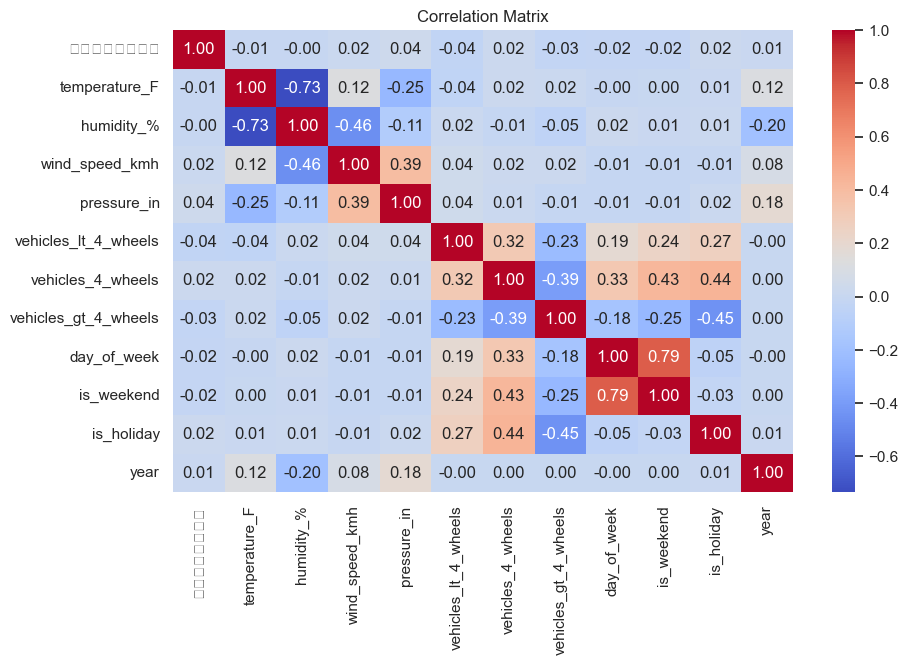

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from c

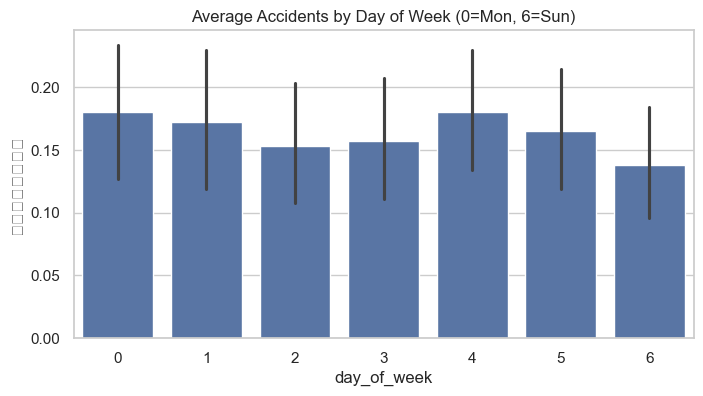

c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from c

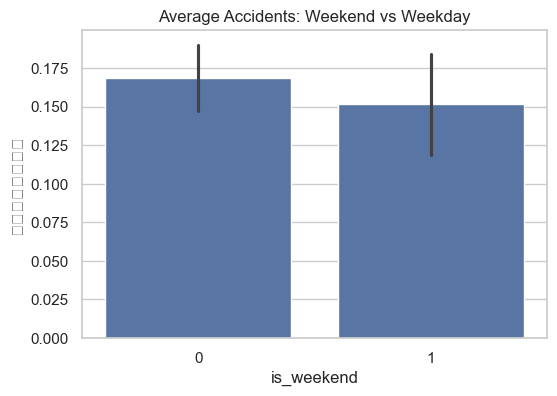

c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sakka\Documents\Years3\venv310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from c

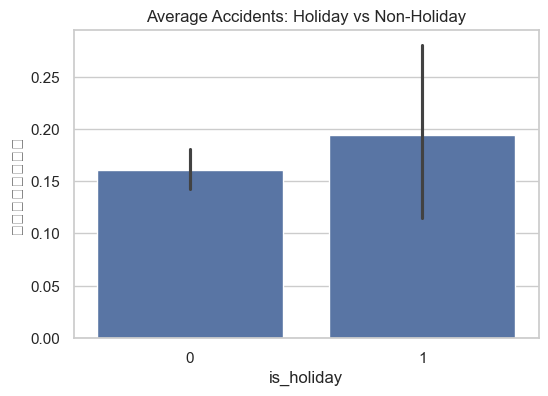

In [8]:
# ค่าเฉลี่ยการเกิดเหตุในแต่ละวัน
plt.figure(figsize=(8,4))
sns.barplot(x='day_of_week', y='เกิดเหตุ', data=df.reset_index())
plt.title('Average Accidents by Day of Week (0=Mon, 6=Sun)')
plt.show()

# วันหยุด vs วันปกติ
plt.figure(figsize=(6,4))
sns.barplot(x='is_weekend', y='เกิดเหตุ', data=df.reset_index())
plt.title('Average Accidents: Weekend vs Weekday')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='is_holiday', y='เกิดเหตุ', data=df.reset_index())
plt.title('Average Accidents: Holiday vs Non-Holiday')
plt.show()


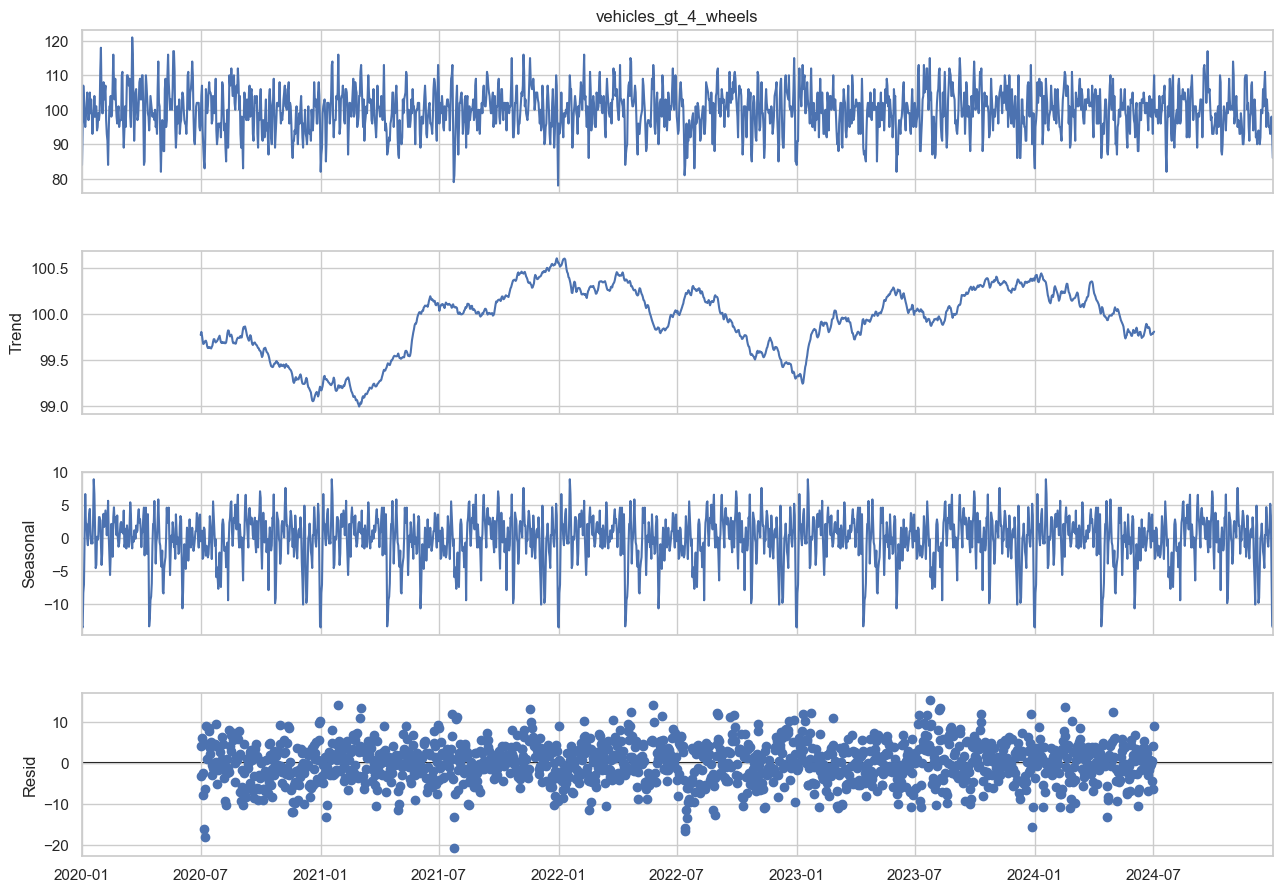

In [9]:
result = seasonal_decompose(df['vehicles_gt_4_wheels'], model='additive', period=365)
fig = result.plot()
fig.set_size_inches(14,10)
plt.show()


In [10]:
adf_result = adfuller(df['vehicles_lt_4_wheels'])
print('ADF Statistic :', adf_result[0])
print('p-value       :', adf_result[1])
for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))


ADF Statistic : -7.8749294157555605
p-value       : 4.8726542084214174e-12
Critical Value (1%): -3.434
Critical Value (5%): -2.863
Critical Value (10%): -2.568


In [11]:
adf_result = adfuller(df['vehicles_4_wheels'])
print('ADF Statistic :', adf_result[0])
print('p-value       :', adf_result[1])
for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))


ADF Statistic : -8.502302525647782
p-value       : 1.2289536694444896e-13
Critical Value (1%): -3.434
Critical Value (5%): -2.863
Critical Value (10%): -2.568


In [12]:
adf_result = adfuller(df['vehicles_gt_4_wheels'])
print('ADF Statistic :', adf_result[0])
print('p-value       :', adf_result[1])
for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))

ADF Statistic : -8.271313207368056
p-value       : 4.784867104680811e-13
Critical Value (1%): -3.434
Critical Value (5%): -2.863
Critical Value (10%): -2.568
